In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Exploration: Load and visualize the data.**

- Use pandas to load the dataset and examine the first few rows.

In [2]:
# Load the .txt file, specifying that values are comma-separated
df = pd.read_csv('data.txt', delimiter=',', header=None)

# Rename columns for clarity
df.columns = ["exam1", "exam2", "admission"]

# Display the first few rows
df.head()

,exam1,exam2,admission
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


In [3]:
df.isnull().sum()

,0
exam1,0
exam2,0
admission,0


- Create a scatter plot to visualize the data points for students who were admitted versus those who were not based on their exam scores.

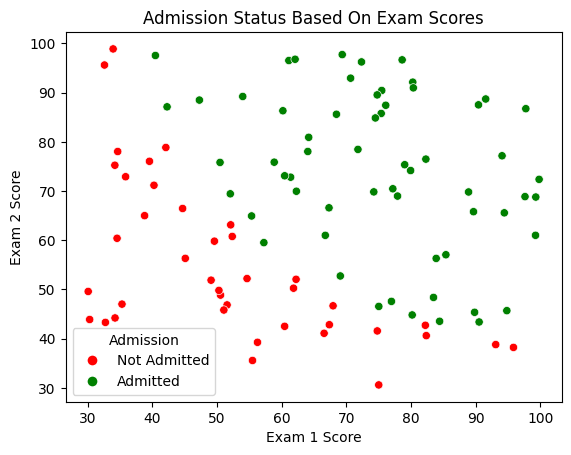

In [4]:
from matplotlib.lines import Line2D

# Create scatter plot
sns.scatterplot(data=df, x="exam1", y="exam2", hue="admission", palette={0: "red", 1: "green"})

# Manually create legend
legend_labels = [Line2D([0], [0], marker='o', color='w', markersize=8, markerfacecolor="red", label="Not Admitted"),
                 Line2D([0], [0], marker='o', color='w', markersize=8, markerfacecolor="green", label="Admitted")]

plt.legend(handles=legend_labels, title="Admission", loc="lower left")

# Add labels and title
plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.title("Admission Status Based On Exam Scores")

plt.show()

**Applying Logistic Regression with scikit-learn:**

- Implement logistic regression using the LogisticRegression function from scikit-learn to find the best parameters for your model.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df.drop(columns=["admission"]) # Keep only features
y = df["admission"] # Target variable

# Split data (train 70%, test 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, test_size=0.30, random_state=1)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


- Train the logistic regression model on your dataset.

In [6]:
# Train logistic regression with balanced class weight
model = LogisticRegression(class_weight='balanced', random_state=1)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=1)

**Making Predictions:**

- Use the trained logistic regression model to make predictions on your dataset.


In [7]:
# Make predictions on test data
y_pred = model.predict(X_test_scaled)

- Calculate the accuracy of your model.


In [8]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")


Accuracy: 0.87


**Model Evaluation:**

- Interpret the result of logistic regression and the accuracy of your model.

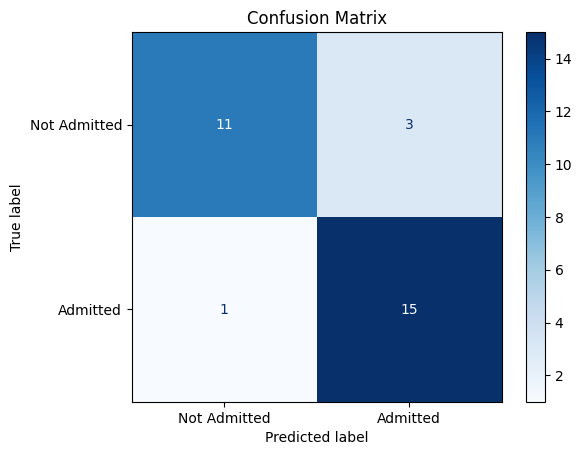

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Admitted", "Admitted"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

- The model achieve an **accuracy of 87%**, meaning **87% of predictions were correct**. This suggests that the logistic regression model performs well in predicting admission based on exam scores.

- Confusion matrix :
  - **True Positives (TP = 15)** → 15 students were admitted and correctly predicted as admitted.
  - **True Negatives (TN = 11)** → 11 students were not admitted and correctly predicted as not admitted.
  - **False Positives (FP = 3)** → 3 students were predicted as admitted but were actually not admitted (wrongly classified).
  - **False Negatives (FN = 1)** → 1 student was predicted as not admitted but was actually admitted (misclassification).

 The model **succesfuly detect most admitted students** (Low false negatives, FN=1).
 Some students were **wrongly classified as admitted** (False positives, FP=3) and 1 (FN=1) **wrongly classified as not admitted**.